In [1]:

import datetime
import os
from pathlib import Path
from src.utils.ModelUtility import model_snapshot
from torch import optim
import torchvision
import torchvision.transforms as transforms

In [2]:
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'#FIXME
print(os.environ["PYTORCH_ENABLE_MPS_FALLBACK"])

1


In [3]:
from src.models.encoder.autoencoder.resnet.RestNetAutoEncoder import ResNet50AutoEncoder

pretrained_model = ResNet50AutoEncoder()

In [4]:
print(pretrained_model.model.encoder)

ResNetEncoder(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): EncoderBottleneckBlock(
    (00 MaxPooling): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (01 EncoderLayer): EncoderBottleneckLayer(
      (weight_layer1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (weight_layer2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (weight_layer3): Sequential(
        (0): Conv2d(64, 256, kernel_size

In [3]:

import torch.nn as nn

class CIFAR10Upscaler(nn.Module):
    def __init__(self):
        super(CIFAR10Upscaler, self).__init__()
        self.conv1 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)  # Keep 3 channels
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # 32x32 -> 64x64
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # 64x64 -> 128x128
        self.upsample3 = nn.Upsample(scale_factor=1.75, mode='bilinear', align_corners=True)  # 128x128 -> 224x224
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.upsample1(x)
        x = self.relu(self.conv2(x))
        x = self.upsample2(x)
        x = self.relu(self.conv3(x))
        x = self.upsample3(x)
        return x


In [4]:
import torch
import torch.nn as nn

class CIFAR10Downscaler(nn.Module):
    def __init__(self):
        super(CIFAR10Downscaler, self).__init__()
        self.conv1 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)  # Keep 3 channels
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)

        # Pooling layers to downscale dimensions
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # 224x224 -> 112x112
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # 112x112 -> 56x56
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)  # 56x56 -> 28x28
        self.upsample_final = nn.Upsample(size=(32, 32), mode='bilinear', align_corners=True)  # 28x28 -> 32x32

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)  # First downscale
        x = self.relu(self.conv2(x))
        x = self.pool2(x)  # Second downscale
        x = self.relu(self.conv3(x))
        x = self.pool3(x)  # Third downscale
        x = self.upsample_final(x)  # Resize to 32x32

        return x


In [5]:
class CombinedModel(nn.Module):
    def __init__(self):
        super(CombinedModel, self).__init__()
        self.upscaler = CIFAR10Upscaler()
        self.pretrained_model = ResNet50AutoEncoder()
        
        for param in self.pretrained_model.parameters():
            param.requires_grad = False
        
        self.downscaler = CIFAR10Downscaler()
        
    def forward(self, x):
        x = self.upscaler(x)
        x = self.pretrained_model(x)
        x = self.downscaler(x)
        return x

In [6]:
dataset = torchvision.datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transforms.ToTensor())
cats_dataset = [(img, label) for (img, label) in dataset if label == 3]
cats_dataloader = torch.utils.data.DataLoader(cats_dataset, batch_size=32, shuffle=True)

Files already downloaded and verified


In [8]:


# Set device to GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'mps:0' if torch.backends.mps.is_available() else 'cpu')

# Move model to device
combined_model = CombinedModel().to(device)

# Initialize optimizer for parameters requiring gradients
optimizer = optim.Adam([param for param in combined_model.parameters() if param.requires_grad], lr=0.001)
criterion = nn.MSELoss()
losses = []
batch_number = cats_dataloader.__len__()
n_epochs = 100
# Training loop
for epoch in range(n_epochs):  # Few epochs to adapt the preprocessor layer

    print(f'\rEpoch {epoch} of {n_epochs}')
    autoencoder_loss = 0

    for images, _ in cats_dataloader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = combined_model(images)

        batch_loss = criterion(outputs, images)

        autoencoder_loss += float(batch_loss.to(
                    'cpu').detach().numpy())/batch_number

        batch_loss.backward()
        optimizer.step()

    print(f"Average loss in the epoch: {autoencoder_loss}")
    losses.append(autoencoder_loss)



Epoch 0 of 100
Average loss in the epoch: 0.05122151842732337
Epoch 1 of 100
Average loss in the epoch: 0.012220880686999518
Epoch 2 of 100
Average loss in the epoch: 0.009922337943723623
Epoch 3 of 100
Average loss in the epoch: 0.009105450915659119
Epoch 4 of 100
Average loss in the epoch: 0.008815515424557928
Epoch 5 of 100
Average loss in the epoch: 0.008664471693455602
Epoch 6 of 100
Average loss in the epoch: 0.008547356091202444
Epoch 7 of 100
Average loss in the epoch: 0.008466718196394335
Epoch 8 of 100
Average loss in the epoch: 0.00831859350607843
Epoch 9 of 100
Average loss in the epoch: 0.008441191154775343
Epoch 10 of 100
Average loss in the epoch: 0.008207172796035262
Epoch 11 of 100
Average loss in the epoch: 0.007961072356908754
Epoch 12 of 100
Average loss in the epoch: 0.00801620468093901
Epoch 13 of 100
Average loss in the epoch: 0.008092524477867945
Epoch 14 of 100
Average loss in the epoch: 0.008186330787457858
Epoch 15 of 100
Average loss in the epoch: 0.00778777

TypeError: model_snapshot() missing 1 required positional argument: 'filename'

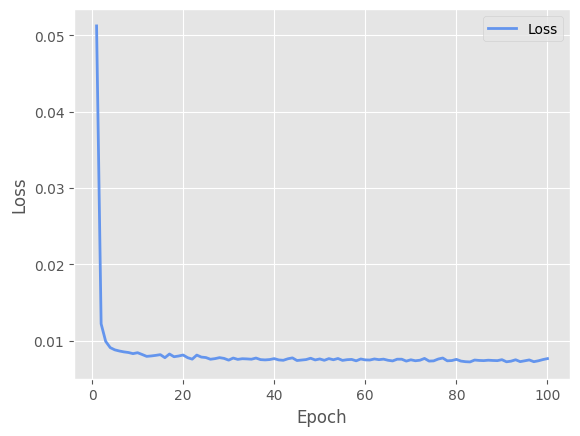

In [9]:
model_snapshot(losses, combined_model, "resnet50_scaled_autoencoder", path_to_directory=Path(os.getcwd()).parent / "experiments" / "pretrained_autoencoder" / f"resnet50_{datetime.datetime.now()}_scaled_autoencoder", run_number=n_epochs)

In [13]:
class ScaledEncoder(nn.Module):
    def __init__(self, filepath):
        super(ScaledEncoder, self).__init__()
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'mps:0' if torch.backends.mps.is_available() else 'cpu')
        autoencoder_model_pth = torch.load(filepath)
        model = CombinedModel().to(device)
        model.load_state_dict(autoencoder_model_pth)
        self.upscaler = model.upscaler
        self.encoder = model.pretrained_model.model.encoder

    def forward(self, x):
        x = self.upscaler(x)
        x = self.encoder(x)
        return x


In [14]:
encoder = ScaledEncoder(
    "../../experiments/pretrained_autoencoder/resnet50_2024-11-17 19:02:26.938377_scaled_autoencoder/train_history/resnet50_scaled_autoencoder_runs_100.pth")

In [15]:
from src.vmmd.VMMDFlattened import VMMD

vmmd = VMMD(epochs=1500, path_to_directory=Path(os.getcwd()).parent / "experiments" /
                 f"Example_normal_{datetime.datetime.now()}_resnet50", lr=0.01, batch_size=1)
vmmd.fit(X=cats_dataset, embedding_function=encoder)

Epoch 0 of 1500


NotImplementedError: The operator 'aten::_cdist_backward' is not currently implemented for the MPS device. If you want this op to be added in priority during the prototype phase of this feature, please comment on https://github.com/pytorch/pytorch/issues/77764. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.